# Exploratory Data Analysis

## Key Findings

1. **The USA is the network's structural chokepoint.** It's the #1 articulation point, tops the systematic vulnerability scan (removing it splits the network from 1 component into 8, shrinking the largest remaining group from 51 nodes down to 43), and ranks #1 in betweenness centrality under both an unweighted and a dollar-weighted formulation. 
2. **Volume concentration and structural fragility are two different risks with two different countries leading each one.** China ($144M) and Brazil (USA's single largest supplier) dominate the network by raw trade volume, but neither appears on the articulation-points list, and removing China from the graph leaves it just as connected as before (1 component → 1 component). A country can be a large trading partner without being a structural chokepoint, and vice versa.
3. **Eight countries are confirmed structural chokepoints, validated by two independent methods that produced an identical list:** USA, Netherlands, Estonia, Poland, Belgium, Germany, Rep. of Korea, and Singapore show up both as articulation points (graph-theoretic cut vertices) and at the top of the exhaustive node-by-node vulnerability scan.
4. **The network is one weakly connected blob.** There is a 12-country subset (Austria, Belgium, Chile, Denmark, Israel, Italy, Japan, Netherlands, Poland, Rep. of Korea, Singapore, USA) that forms a bidirectional core with cyclical trade relationships. The other 39 countries sit in one-way dead-end relationships with no path back, largely because 28 of the 51 nodes are "partner-only", meaning they were named as a source by others but never reporting their own imports.
5. **Community detection surfaces 4 distinct trading clusters** (e.g., a USA/Canada/Japan-anchored group, a Central European cluster, a Western European cluster, and an Asia-Pacific cluster centered on China/Rep. of Korea/Singapore), suggesting that a regional disruption (a single country's export ban, a regional conflict, a shipping corridor closure) could plausibly impact an entire cluster of trading partners simultaneously, not just one node in isolation.

## Imports

In [1]:
import os

import pandas as pd
import numpy as np

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

from pyvis.network import Network
import matplotlib.pyplot as plt

## Pre-Cleaning Checks

This section will inform which tasks the data-cleaning.py file needs to perform in order to get the data ready for the graph database.

### Findings

1. Raw file contains 55 reporters, each with a world aggregate row and partner rows (where available).
2. 11% of rows are world-total or other aggregate rows and will be excluded from edge construction to avoid double counting.
3. FOB value has over 70% of its data missing. The FOB value is mainly important to exports so this column can be dropped.
4. 32 reporters have a world total but no partners. They will be included in the graph as nodes but will not have any outgoing relationships.

In [2]:
raw = pd.read_csv("../data/raw/comtrade_gallium_imports_2025_raw.csv")

pd.set_option('display.max_columns', None)
raw.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,flowDesc,partnerCode,partnerISO,partnerDesc,partner2Code,partner2ISO,partner2Desc,classificationCode,classificationSearchCode,isOriginalClassification,cmdCode,cmdDesc,aggrLevel,isLeaf,customsCode,customsDesc,mosCode,motCode,motDesc,qtyUnitCode,qtyUnitAbbr,qty,isQtyEstimated,altQtyUnitCode,altQtyUnitAbbr,altQty,isAltQtyEstimated,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20250101,2025,52,2025,842,USA,USA,M,Import,0,W00,World,0,W00,World,H6,HS,True,811292,"Gallium, germanium, indium, niobium (columbium...",6,True,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,1912812.0,False,8,kg,1912812.0,False,1912693.0,False,0.0,False,208883040.0,207646575.0,208883040.0,0,False,True
1,C,A,20250101,2025,52,2025,842,USA,USA,M,Import,40,AUT,Austria,0,W00,World,H6,HS,True,811292,"Gallium, germanium, indium, niobium (columbium...",6,True,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,6470.0,False,8,kg,6470.0,False,6470.0,False,0.0,False,328547.0,325461.0,328547.0,0,True,False
2,C,A,20250101,2025,52,2025,842,USA,USA,M,Import,56,BEL,Belgium,0,W00,World,H6,HS,True,811292,"Gallium, germanium, indium, niobium (columbium...",6,True,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,10935.0,False,8,kg,10935.0,False,10935.0,False,0.0,False,13982700.0,13910992.0,13982700.0,0,True,False
3,C,A,20250101,2025,52,2025,842,USA,USA,M,Import,76,BRA,Brazil,0,W00,World,H6,HS,True,811292,"Gallium, germanium, indium, niobium (columbium...",6,True,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,1329811.0,False,8,kg,1329811.0,False,1329811.0,False,0.0,False,64630750.0,64269892.0,64630750.0,0,True,False
4,C,A,20250101,2025,52,2025,842,USA,USA,M,Import,124,CAN,Canada,0,W00,World,H6,HS,True,811292,"Gallium, germanium, indium, niobium (columbium...",6,True,C00,TOTAL CPC,0,0,TOTAL MOT,8,kg,77848.0,False,8,kg,77848.0,False,77732.0,False,0.0,False,19836079.0,19799580.0,19836079.0,0,True,False


In [3]:
# Check for unique values in columns of interest

print(f"Rows: {len(raw)}")
print(f"Reporters: {raw['reporterDesc'].nunique()}\n {sorted(raw['reporterDesc'].unique().tolist())}")
print(f"Partners: {raw['partnerDesc'].nunique()}\n {sorted(raw['partnerDesc'].unique().tolist())}")
print(f"Commodity Codes: {sorted(raw['cmdCode'].unique().tolist())}")
print(f"Flow types: {sorted(raw['flowDesc'].unique().tolist())}")
print(f"Reference Years: {sorted(raw['refYear'].unique().tolist())}")

Rows: 479
Reporters: 55
 ['Australia', 'Austria', 'Azerbaijan', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China, Hong Kong SAR', 'Colombia', 'Croatia', 'Czechia', 'Denmark', 'Egypt', 'El Salvador', 'Estonia', 'European Union', 'Faroe Isds', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Philippines', 'Poland', 'Portugal', 'Rep. of Korea', 'Rep. of Moldova', 'Romania', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Türkiye', 'USA', 'United Kingdom']
Partners: 55
 ['Areas, nes', 'Armenia', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'China, Hong Kong SAR', 'Colombia', 'Congo', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'France', 'Germany', 'Hungary', 'India', 'Ireland', 'Israel',

In [4]:
# Check which rows are aggregates or self-trades and how many are left after filtering them out

world_mask = raw['partnerDesc'].str.strip().str.lower() == 'world'
agg_mask = raw['isAggregate'] == True
self_mask = raw['reporterDesc'] == raw['partnerDesc']

print(f"World total rows: {world_mask.sum()}, ({world_mask.sum() / len(raw) * 100:.2f}% of raw rows)")
print(f"Other aggregate rows (non-world): {((agg_mask) & (~world_mask)).sum()}")
print(f"Self-trade rows: {self_mask.sum()}")
print(f"Rows remaining after filtering world, aggregate, and self-trade rows: {((~world_mask) & (~agg_mask) & (~self_mask)).sum()}")


World total rows: 55, (11.48% of raw rows)
Other aggregate rows (non-world): 253
Self-trade rows: 2
Rows remaining after filtering world, aggregate, and self-trade rows: 171


In [5]:
# Count missing values

null_counts = raw.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print(f"Columns with missing values:\n {null_counts}")
print(f"Percentage of missing values per column:\n {null_counts / len(raw) * 100}")

Columns with missing values:
 fobvalue          355
altQtyUnitAbbr     95
cifvalue           21
dtype: int64
Percentage of missing values per column:
 fobvalue          74.112735
altQtyUnitAbbr    19.832985
cifvalue           4.384134
dtype: float64


In [6]:
# Check which reporters have no partner data

no_partner_data = raw[raw['partnerDesc'].isnull()]['reporterDesc'].unique()
no_partner_data

<StringArray>
[]
Length: 0, dtype: str

In [7]:
world_totals = (
    raw[world_mask]
    .groupby("reporterDesc", as_index=False)["primaryValue"]
    .sum()
    .rename(columns={"primaryValue": "world_total_value"})
)

partner_sums = (
    raw[~world_mask & ~agg_mask & ~self_mask]
    .groupby("reporterDesc", as_index=False)["primaryValue"]
    .sum()
    .rename(columns={"primaryValue": "sum_of_partners_value"})
)

mismatch = world_totals.merge(partner_sums, on="reporterDesc", how="left")

print(f"Reporters with world total but no partner data: {mismatch[mismatch['sum_of_partners_value'].isna()]['reporterDesc'].tolist()}")
print(f"There are {len(mismatch[mismatch['sum_of_partners_value'].isna()])} reporters with world total but no partner data.")

Reporters with world total but no partner data: ['Australia', 'Azerbaijan', 'Brazil', 'Canada', 'Colombia', 'Czechia', 'Estonia', 'European Union', 'Faroe Isds', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Indonesia', 'Latvia', 'Luxembourg', 'Malaysia', 'Norway', 'Portugal', 'Rep. of Moldova', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom']
There are 32 reporters with world total but no partner data.


## Graph Setup

In [8]:
# Create networkx graph from pandas dataframes

edges = pd.read_csv("../data/processed/cleaned_edges.csv")
nodes = pd.read_csv("../data/processed/cleaned_nodes.csv")

graph = nx.from_pandas_edgelist(edges, 
                                source="source", 
                                target="target", 
                                edge_attr=["trade_value_usd", "trade_qty_kg", "share_of_reporter_total", "year", "cmd_code"],
                                create_using=nx.DiGraph())

print(f"Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")

Nodes: 51, Edges: 171


In [9]:
# Make sure countries with no outgoing edges have metadata explicitly 

node_attrs = nodes.set_index("country").to_dict(orient="index")
nx.set_node_attributes(graph, node_attrs)

# Check that every row in the graph has a matching row in cleaned_nodes.csv
missing = set(graph.nodes() - set(nodes["country"]))
print(f"Nodes in graph but missing from node table: {missing}")

Nodes in graph but missing from node table: set()


In [10]:
net = Network(height="750px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

for node in graph.nodes():
    attrs = graph.nodes[node]
    raw_value = attrs.get("total_import_value_usd")
    value = raw_value if pd.notna(raw_value) else 0
    size = 10 + value / 5e6
    color = "#e74c3c" if attrs.get("is_partner_only") else "#3498db"
    net.add_node(node, label=node, size=size, color=color, title=str(attrs))

for u, v, attrs in graph.edges(data=True):
    weight = attrs.get("trade_value_usd", 0)
    net.add_edge(u, v, value=weight / 1e5, title=f"${weight:,.0f}")

net.show("gallium_network.html")

gallium_network.html


## Exploratory Data Analysis

### Weakly Connected Analysis

In [11]:
# Discover weak connections
print(f"Is connected weakly: {nx.is_weakly_connected(graph)}")
print(f"Number of weakly connected components: {nx.number_weakly_connected_components(graph)}")

# Find largest component
largest_cc = max(nx.weakly_connected_components(graph), key=len)
print(f"Largest component size: {len(largest_cc)} of {graph.number_of_nodes()} nodes.")

Is connected weakly: True
Number of weakly connected components: 1
Largest component size: 51 of 51 nodes.


In [12]:
# Degrees of connection

in_deg = dict(graph.in_degree())    # how many countries this country supplies to
out_deg = dict(graph.out_degree())  # how many countries this country imports from

# Total dollar value flowing in and out 

in_strength = dict(graph.in_degree(weight="trade_value_usd"))
out_strength = dict(graph.out_degree(weight="trade_value_usd"))

# Countries of centrality

centrality_df = pd.DataFrame({
    "country": list(graph.nodes()),
    "in_degree": [in_deg[n] for n in graph.nodes()],
    "out_degree": [out_deg[n] for n in graph.nodes()],
    "in_strength_millions_usd": [round(in_strength[n]/1e6, 2) for n in graph.nodes()] # change this into dolla values
}).sort_values("in_strength_millions_usd", ascending=False)

centrality_df.head(10)

,country,in_degree,out_degree,in_strength_millions_usd
3,China,13,0,144.18
32,Brazil,3,0,79.36
10,Rep. of Korea,9,15,43.81
22,"Other Asia, nes",6,0,35.87
1,Germany,16,0,32.90
17,Canada,10,0,27.21
7,Japan,7,12,19.42
2,USA,17,29,17.35
6,Belgium,5,18,14.54
5,Netherlands,5,20,8.29


In [14]:
# Betweenness centrality
for u, v, d in graph.edges(data=True):
    d["distance"] = 1 / d["trade_value_usd"] if d["trade_value_usd"] > 0 else float("inf")
betweenness_weighted = nx.betweenness_centrality(graph, weight="distance")
betweenness_df = pd.DataFrame(betweenness_weighted.items(), columns=["country", "betweenness"]).sort_values("betweenness", ascending=False)
betweenness_df.head(10)

,country,betweenness
2,USA,0.253469
6,Belgium,0.077143
7,Japan,0.076327
10,Rep. of Korea,0.046939
5,Netherlands,0.039184
13,Italy,0.026939
38,Poland,0.015510
21,Singapore,0.007755
35,Morocco,0.000000
37,Hungary,0.000000


In [ ]:
# Betweenness with dollar value
betweenness = nx.betweenness_centrality(graph, weight="trade_value_usd")
betweenness_df = pd.DataFrame(betweenness.items(), columns=["country", "betweenness"]).sort_values("betweenness", ascending=False)
betweenness_df.head(10)

,country,betweenness
2,USA,0.182857
13,Italy,0.148163
6,Belgium,0.094286
5,Netherlands,0.077143
10,Rep. of Korea,0.046531
38,Poland,0.017551
11,Israel,0.015918
0,Austria,0.011020
7,Japan,0.010612
24,Denmark,0.009388


### Strongly Connected Analysis

In [ ]:
# Discover strong connections
print(f"Is strongly connected: {nx.is_strongly_connected(graph)}")
print(f"Number of strongly connected components: {nx.number_strongly_connected_components(graph)}")

# Distribution of strongly connected component sizes
scc_sizes = sorted([len(c) for c in nx.strongly_connected_components(graph)], reverse=True)
print(f"Strongly connected component sizes: {scc_sizes}")

# Largest strongly connected component
largest_scc = max(nx.strongly_connected_components(graph), key=len)
print(f"Largest strongly connected component: {len(largest_scc)} nodes -> {sorted(largest_scc)}")

Is strongly connected: False
Number of strongly connected components: 40
Strongly connected component sizes: [12, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Largest strongly connected component: 12 nodes -> ['Austria', 'Belgium', 'Chile', 'Denmark', 'Israel', 'Italy', 'Japan', 'Netherlands', 'Poland', 'Rep. of Korea', 'Singapore', 'USA']


### Degree Distribution

The histograms below show the in-degree and out-degree distributions. Both plots are heavily right skewed, with many countries falling between 0-1. This indicates that most countries are only supplying or being supplied by 1 other country, but there are a few hubs with larger connections. 

Text(0.5, 1.0, 'Out-degree distribution')

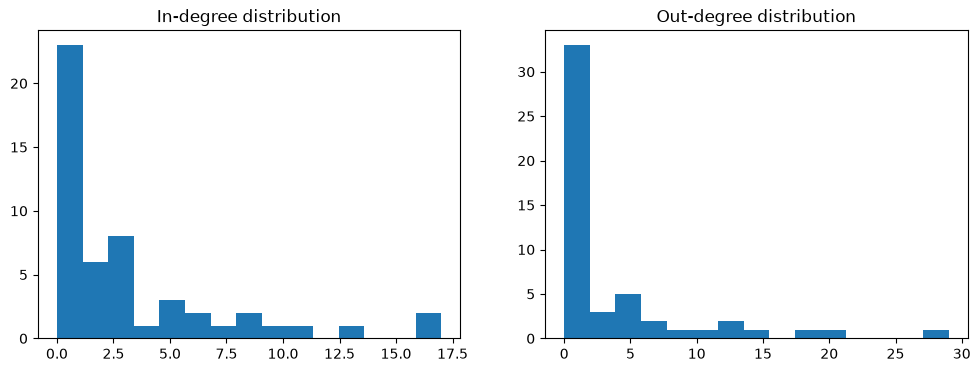

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist([d for n, d in graph.in_degree()], bins=15)
axes[0].set_title("In-degree distribution")

axes[1].hist([d for n, d in graph.out_degree()], bins=15)
axes[1].set_title("Out-degree distribution")

### PageRank

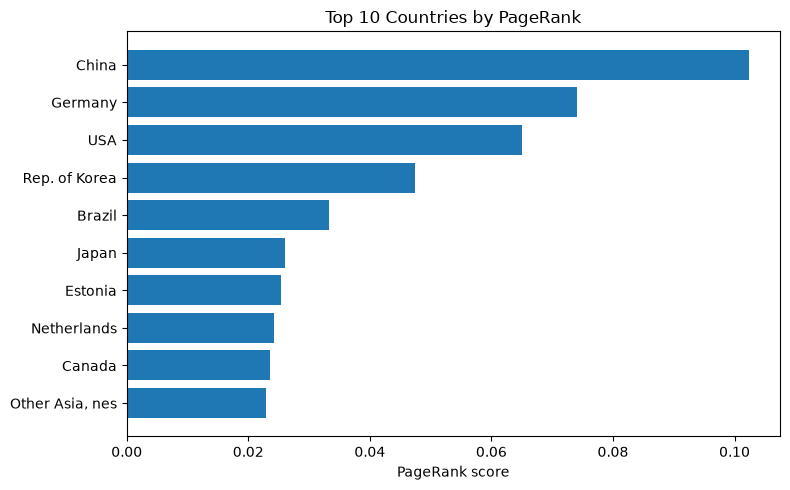

In [15]:
pagerank = nx.pagerank(graph, weight="trade_value_usd")
pagerank_df = pd.DataFrame(pagerank.items(), columns=["country", "pagerank"]).sort_values("pagerank", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
top10 = pagerank_df.head(10)
ax.barh(top10["country"][::-1], top10["pagerank"][::-1])
ax.set_title("Top 10 Countries by PageRank")
ax.set_xlabel("PageRank score")
plt.tight_layout()
plt.show()

### Closeness Centrality

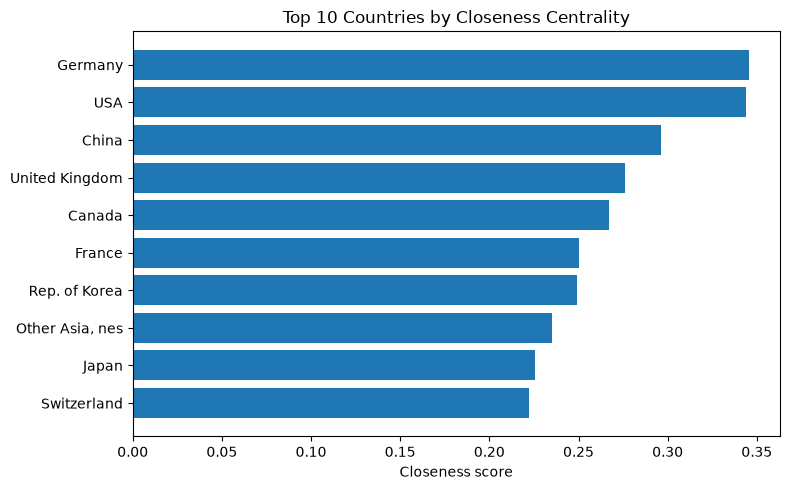

In [ ]:
# Closeness centrality - how easily can a node be reached by other nodes
closeness = nx.closeness_centrality(graph)
closeness_df = pd.DataFrame(closeness.items(), columns=["country", "closeness"]).sort_values("closeness", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
top10 = closeness_df.head(10)
ax.barh(top10["country"][::-1], top10["closeness"][::-1])
ax.set_title("Top 10 Countries by Closeness Centrality")
ax.set_xlabel("Closeness score")
plt.tight_layout()
plt.show()

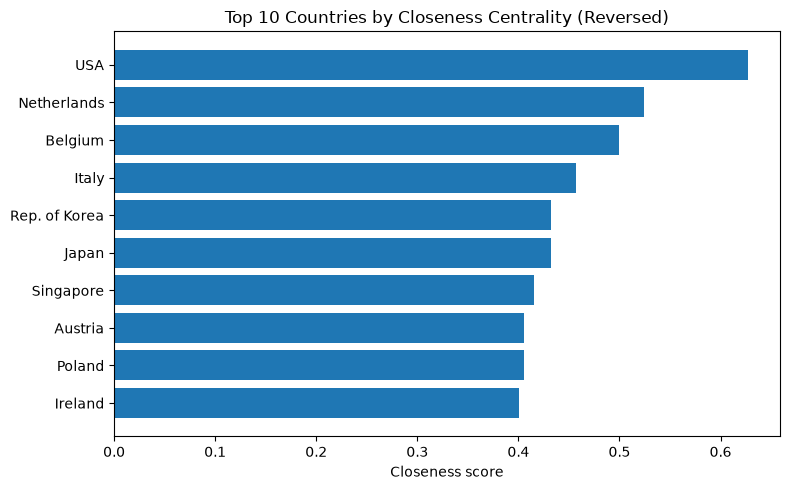

In [ ]:
# Reverse closeness centrality - how quickly can a node reach other nodes? (a country reaching an alternate supplier)
closeness_reversed = nx.closeness_centrality(graph.reverse())
closeness_reversed_df = pd.DataFrame(closeness_reversed.items(), columns=["country", "closeness_reversed"]).sort_values("closeness_reversed", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
top10 = closeness_reversed_df.head(10)
ax.barh(top10["country"][::-1], top10["closeness_reversed"][::-1])
ax.set_title("Top 10 Countries by Closeness Centrality (Reversed)")
ax.set_xlabel("Closeness score")
plt.tight_layout()
plt.show()

### Articulation points and bridges

In [ ]:
undirected = graph.to_undirected()
cut_vertices = list(nx.articulation_points(undirected))
cut_edges = list(nx.bridges(undirected))

print(f"Articulation points: {cut_vertices}")
print(f"Bridges: {cut_edges}")

Articulation points: ['Belgium', 'Poland', 'Singapore', 'Rep. of Korea', 'Netherlands', 'Estonia', 'USA', 'Germany']
Bridges: [('Germany', 'El Salvador'), ('USA', 'Chile'), ('USA', 'Kazakhstan'), ('USA', 'Ukraine'), ('USA', 'Finland'), ('USA', 'Colombia'), ('USA', 'Thailand'), ('USA', 'Sri Lanka'), ('Netherlands', 'Portugal'), ('Netherlands', 'Hungary'), ('Belgium', 'Romania'), ('Rep. of Korea', 'Croatia'), ('Singapore', 'Australia'), ('Iceland', 'Estonia'), ('Poland', 'Bulgaria')]


### Systematic vulnerability scan

In [ ]:
results = []

for node in graph.nodes:
    g_temp = graph.copy()
    g_temp.remove_node(node)
    n_components = nx.number_weakly_connected_components(g_temp)
    largest_cc = len(max(nx.weakly_connected_components(g_temp), key=len)) if g_temp.number_of_nodes() else 0
    results.append({"country": node, "components_after_removal": n_components, "largest_component_after": largest_cc})

vulnerability_df = pd.DataFrame(results).sort_values("components_after_removal", ascending=False)
vulnerability_df.head(10)

,country,components_after_removal,largest_component_after
2,USA,8,43
5,Netherlands,3,48
28,Estonia,2,49
38,Poland,2,49
6,Belgium,2,49
1,Germany,2,49
10,Rep. of Korea,2,49
21,Singapore,2,49
30,India,1,50
31,Luxembourg,1,50


### Community Detection

In [ ]:
communities = greedy_modularity_communities(undirected, weight="trade_value_usd")
communities

[frozenset({'Brazil',
            'Canada',
            'Chile',
            'Colombia',
            'El Salvador',
            'Estonia',
            'Finland',
            'Germany',
            'Iceland',
            'Ireland',
            'Japan',
            'Kazakhstan',
            'Malaysia',
            'Morocco',
            'New Zealand',
            'Other Asia, nes',
            'Philippines',
            'Russian Federation',
            'Slovakia',
            'Sri Lanka',
            'Thailand',
            'USA',
            'Ukraine',
            'United Kingdom'}),
 frozenset({'Austria',
            'Belgium',
            'Czechia',
            'India',
            'Israel',
            'Lithuania',
            'Romania',
            'Spain',
            'Sweden',
            'Switzerland'}),
 frozenset({'Bulgaria',
            'Denmark',
            'France',
            'Hungary',
            'Italy',
            'Luxembourg',
            'Netherlands',
           